# **Advanced Optimization Methods: A Comprehensive Guide to Accelerated Training**

**Course:** Deep Learning and Generative AI  
**Institution:** IIT Madras  
**Author:** Prof. Balaji Srinivasan

**Date:** October, 2025  

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** the mathematical foundations of advanced optimization algorithms
2. **Implement** Momentum, Nesterov Momentum, Adagrad, RMSProp, Adam, AdamW, and AdaDelta from scratch
3. **Compare** the convergence properties and performance characteristics of different optimizers
4. **Apply** appropriate optimizers for specific machine learning problems
5. **Analyze** the behavior of optimization algorithms through practical demonstrations
6. **Utilize** PyTorch's built-in optimizer implementations effectively

---

## **Prerequisites**

- Solid understanding of gradient descent and backpropagation
- Familiarity with PyTorch tensor operations and autograd
- Knowledge of calculus, linear algebra, and optimization theory
- Understanding of the PyTorch workflow for model training

## **1. Overview and Theoretical Framework**

### **1.1 The Challenge of Vanilla Gradient Descent**

**Gradient descent**, while powerful, faces several fundamental challenges that limit its effectiveness in deep learning:

1. **Slow Convergence**: Especially in ravines and regions with high curvature
2. **Oscillations**: In dimensions with high gradients while progressing slowly in dimensions with small gradients
3. **Saddle Points**: Getting stuck in regions where gradients are near zero
4. **Learning Rate Sensitivity**: A single global learning rate may not be appropriate for all parameters

**Advanced optimization methods address these limitations** by introducing adaptive mechanisms, momentum-based approaches, and parameter-specific learning rates.

### **1.2 Evolution of Optimization Algorithms**

The development of optimization algorithms follows a clear progression:

```
Vanilla GD → Momentum → Nesterov → Adaptive Methods (Adagrad, RMSProp, AdaDelta) → Adam Family (Adam, AdamW)
```

Each advancement addresses specific limitations of previous methods while introducing new capabilities for faster and more reliable convergence.

### **1.3 Optimization Algorithm Comparison**

| **Algorithm** | **Key Innovation** | **Advantages** | **Limitations** |
|---------------|-------------------|----------------|----------------|
| **Vanilla GD** | Basic gradient descent | Simple, guaranteed convergence for convex | Slow, oscillations, fixed LR |
| **Momentum** | Accumulates past gradients | Faster convergence, reduced oscillation | Requires tuning β₁ |
| **Nesterov** | Look-ahead gradient | Better convergence in convex cases | More complex computation |
| **Adagrad** | Per-parameter adaptive LR | Good for sparse data | Learning rate decay too aggressive |
| **RMSProp** | Exponential moving average of squared gradients | Addresses Adagrad's decay issue | Still requires manual LR tuning |
| **AdaDelta** | No learning rate required | Robust, self-adaptive | Can be slower than Adam |
| **Adam** | Combines momentum + RMSProp | Fast, works well in practice | May not converge in some cases |
| **AdamW** | Decoupled weight decay | Better generalization | Requires additional hyperparameter |

## **2. Environment Setup and Imports**

In [1]:
# Import essential libraries for optimization demonstrations
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import time
from typing import Dict, List, Tuple, Callable
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for high-quality visualizations
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Verify PyTorch installation and system configuration
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

PyTorch Version: 2.8.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Device: Tesla T4
Using device: cuda


## **3. Vanilla Gradient Descent (GD)**

### **3.1 Mathematical Foundation**

**Vanilla Gradient Descent** is the foundational optimization algorithm that updates parameters in the direction opposite to the gradient of the loss function.

**Update Rule:**

$$\theta_{t+1} = \theta_t - \alpha \nabla_\theta J(\theta_t)$$

Where:
- $\theta_t$ : Parameters at iteration $t$
- $\alpha$ : Learning rate (step size)
- $\nabla_\theta J(\theta_t)$ : Gradient of loss function with respect to parameters
- $J(\theta)$ : Loss function

**Key Characteristics:**
1. **Simple and intuitive**: Directly follows the negative gradient
2. **Fixed learning rate**: Same step size for all parameters and iterations
3. **No memory**: Each update is independent of previous updates
4. **Guaranteed convergence** for convex functions with appropriate learning rate

**Limitations:**
- Oscillates in ravines (areas with steep curvature in one dimension and gentle in another)
- Slow convergence in regions with small gradients
- Requires careful learning rate tuning
- Gets stuck in local minima or saddle points

### **3.2 Implementation from Scratch**

In [2]:
class VanillaGD:
    """
    Vanilla Gradient Descent Optimizer Implementation.

    Implements the basic gradient descent update rule without any
    momentum or adaptive learning rate mechanisms.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate (step size)
    """

    def __init__(self, params, lr=0.01):
        """Initialize optimizer with parameters and learning rate."""
        self.params = list(params)
        self.lr = lr

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step.

        Updates parameters using the vanilla gradient descent rule:
        θ_new = θ_old - α * ∇θ
        """
        with torch.no_grad():
            for param in self.params:
                if param.grad is not None:
                    # Apply gradient descent update
                    param -= self.lr * param.grad

# Test the implementation
print("Vanilla Gradient Descent Optimizer Initialized Successfully")
print(f"Update Rule: θ_new = θ_old - α * ∇θ")

Vanilla Gradient Descent Optimizer Initialized Successfully
Update Rule: θ_new = θ_old - α * ∇θ


## **4. Momentum-Based Optimization**

### **4.1 Classical Momentum**

#### **4.1.1 Mathematical Foundation**

**Momentum optimization** addresses the oscillation problem by accumulating a velocity vector in directions of consistent gradient descent, resulting in faster convergence.

**Update Rules:**

$$v_t = \beta v_{t-1} + \nabla_\theta J(\theta_t)$$

$$\theta_{t+1} = \theta_t - \alpha v_t$$

Where:
- $v_t$ : Velocity (accumulated gradient)
- $\beta$ : Momentum coefficient (typically 0.9)
- $\alpha$ : Learning rate

**Physical Analogy:**
Imagine a ball rolling down a hill. Momentum helps the ball:
1. **Accelerate** in directions of consistent downward slope
2. **Dampen oscillations** in directions with conflicting gradients
3. **Escape shallow local minima** by maintaining velocity

**Key Advantages:**
- Faster convergence in relevant directions
- Reduced oscillations in high-curvature regions
- Better navigation through plateaus and ravines
- Helps escape saddle points

**Typical Hyperparameter Settings:**
- $\beta = 0.9$ (standard)
- $\beta = 0.99$ (for very large models or smooth optimization landscapes)

#### **4.1.2 Implementation from Scratch**

In [10]:
class MomentumOptimizer:
    """
    Momentum Optimization Implementation.

    Accumulates velocity in directions of persistent gradient reduction,
    accelerating convergence and reducing oscillations.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate
    momentum : float
        Momentum coefficient β (typically 0.9)
    """

    def __init__(self, params, lr=0.01, momentum=0.9):
        """Initialize optimizer with parameters, learning rate, and momentum."""
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        # Initialize velocity for each parameter
        self.velocities = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with momentum.

        Update rules:
        v_t = β * v_{t-1} + ∇θ
        θ_new = θ_old - α * v_t
        """
        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Update velocity: v_t = β * v_{t-1} + gradient
                    self.velocities[i] = self.momentum * self.velocities[i] + param.grad

                    # Update parameters: θ = θ - α * v_t
                    param -= self.lr * self.velocities[i]

### **4.2 Nesterov Accelerated Gradient (NAG)**

#### **4.2.1 Mathematical Foundation**

**Nesterov Momentum** is a smarter variant that looks ahead before computing the gradient, enabling more informed updates and faster convergence.

**Update Rules:**

$$v_t = \beta v_{t-1} + \nabla_\theta J(\theta_t - \alpha \beta v_{t-1})$$

$$\theta_{t+1} = \theta_t - \alpha v_t$$

**Key Innovation - The "Look-Ahead":**

Instead of computing the gradient at the current position $\theta_t$, Nesterov momentum computes it at an approximate future position $\theta_t - \alpha \beta v_{t-1}$. This provides a form of error correction.

**Intuitive Explanation:**
- **Classical Momentum**: "I'm going in this direction with this velocity, let me check the gradient"
- **Nesterov Momentum**: "I'm about to go in this direction, let me check the gradient there first"

**Advantages over Classical Momentum:**
1. **Better convergence rate** for convex functions: $O(1/t^2)$ vs $O(1/t)$
2. **More responsive** to changes in gradient direction
3. **Reduced overshooting** in optimization landscape
4. **Theoretically superior** convergence guarantees

**Practical Considerations:**
- More computationally expensive (requires extra gradient computation conceptually)
- PyTorch implements an equivalent efficient formulation
- Benefits are most pronounced in convex optimization
- For non-convex deep learning, benefits over classical momentum are often marginal

#### **4.2.2 Implementation from Scratch**

In [11]:
class NesterovOptimizer:
    """
    Nesterov Accelerated Gradient (NAG) Implementation.

    Implements look-ahead momentum that evaluates gradients at
    the approximate future position, enabling more informed updates.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate
    momentum : float
        Momentum coefficient β (typically 0.9)
    """

    def __init__(self, params, lr=0.01, momentum=0.9):
        """Initialize optimizer with parameters, learning rate, and momentum."""
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        # Initialize velocity for each parameter
        self.velocities = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with Nesterov momentum.

        This implementation uses the efficient reformulation:
        v_t = β * v_{t-1} + ∇θ
        θ_new = θ_old - α * (β * v_t + ∇θ)

        which is equivalent to the original Nesterov formulation but
        requires only one gradient computation.
        """
        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Update velocity
                    self.velocities[i] = self.momentum * self.velocities[i] + param.grad

                    # Nesterov update: look ahead by applying momentum to velocity
                    param -= self.lr * (self.momentum * self.velocities[i] + param.grad)

## **5. Adaptive Learning Rate Methods**

### **5.1 Adagrad (Adaptive Gradient Algorithm)**

#### **5.1.1 Mathematical Foundation**

**Adagrad** adapts the learning rate for each parameter based on the historical gradients, giving frequently updated parameters smaller learning rates and infrequent parameters larger learning rates.

**Update Rules:**

$$G_t = G_{t-1} + (\nabla_\theta J(\theta_t))^2$$

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{G_t + \epsilon}} \odot \nabla_\theta J(\theta_t)$$

Where:
- $G_t$ : Sum of squared gradients (accumulated)
- $\epsilon$ : Small constant for numerical stability (typically $10^{-8}$)
- $\odot$ : Element-wise multiplication

**Key Innovation - Parameter-Specific Learning Rates:**

Each parameter gets its own adaptive learning rate based on its gradient history:
- **Frequent updates** (large $G_t$) → **Smaller effective learning rate**
- **Infrequent updates** (small $G_t$) → **Larger effective learning rate**

**Advantages:**
1. **Eliminates need for manual learning rate tuning** (to some extent)
2. **Excellent for sparse data** (e.g., NLP with word embeddings)
3. **Adapts to parameter importance** automatically
4. **Works well with sparse gradients**

**Critical Limitation - Aggressive Decay:**

The continual accumulation of squared gradients causes the learning rate to shrink monotonically:

$$\lim_{t \to \infty} \frac{\alpha}{\sqrt{G_t}} = 0$$

This can cause premature convergence where learning essentially stops before reaching the optimum.

**Practical Applications:**
- Natural Language Processing (sparse features)
- Recommender systems (sparse user-item interactions)
- Problems with highly varying feature frequencies

#### **5.1.2 Implementation from Scratch**

In [12]:
class AdagradOptimizer:
    """
    Adagrad (Adaptive Gradient) Optimizer Implementation.

    Adapts learning rates based on cumulative squared gradients,
    providing larger updates for infrequent parameters.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate (typically 0.01)
    eps : float
        Small constant for numerical stability (default: 1e-8)
    """

    def __init__(self, params, lr=0.01, eps=1e-8):
        """Initialize optimizer with parameters and hyperparameters."""
        self.params = list(params)
        self.lr = lr
        self.eps = eps
        # Initialize sum of squared gradients for each parameter
        self.sum_squared_grads = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with Adagrad.

        Update rules:
        G_t = G_{t-1} + (∇θ)²
        θ_new = θ_old - (α / √(G_t + ε)) * ∇θ
        """
        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Accumulate squared gradients
                    self.sum_squared_grads[i] += param.grad ** 2

                    # Compute adaptive learning rate
                    adapted_lr = self.lr / (torch.sqrt(self.sum_squared_grads[i]) + self.eps)

                    # Update parameters with adaptive learning rate
                    param -= adapted_lr * param.grad

### **5.2 RMSProp (Root Mean Square Propagation)**

#### **5.2.1 Mathematical Foundation**

**RMSProp** addresses Adagrad's aggressive learning rate decay by using an exponentially decaying average of squared gradients instead of accumulating all past gradients.

**Update Rules:**

$$E[g^2]_t = \beta E[g^2]_{t-1} + (1-\beta)(\nabla_\theta J(\theta_t))^2$$

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{E[g^2]_t + \epsilon}} \odot \nabla_\theta J(\theta_t)$$

Where:
- $E[g^2]_t$ : Exponential moving average of squared gradients
- $\beta$ : Decay rate (typically 0.9 or 0.99)
- $\alpha$ : Learning rate
- $\epsilon$ : Small constant for numerical stability

**Key Innovation - Exponential Moving Average:**

Unlike Adagrad's cumulative sum, RMSProp uses a moving window:
- **Recent gradients** have more influence
- **Old gradients** decay exponentially
- **Learning rate doesn't monotonically decrease**

**Advantages over Adagrad:**
1. **Resolves diminishing learning rate problem**
2. **Better suited for non-stationary objectives** (e.g., online learning)
3. **More suitable for RNNs and deep networks**
4. **Maintains learning capability throughout training**

**Mathematical Insight:**

The exponential moving average effectively implements:

$$E[g^2]_t \approx \frac{1}{1-\beta} \sum_{i=1}^{t} \beta^{t-i} g_i^2$$

With $\beta = 0.9$, approximately the last 10 gradient updates significantly influence the learning rate.

**Practical Considerations:**
- Developed by Geoff Hinton in his Coursera lecture (never formally published!)
- Works well with RNNs and non-stationary problems
- Still requires manual learning rate tuning
- Typical hyperparameters: $\alpha = 0.001$, $\beta = 0.9$

#### **5.2.2 Implementation from Scratch**

In [13]:
class RMSPropOptimizer:
    """
    RMSProp (Root Mean Square Propagation) Optimizer Implementation.

    Uses exponentially decaying average of squared gradients to adapt
    learning rates, addressing Adagrad's aggressive decay problem.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate (typically 0.001)
    beta : float
        Decay rate for moving average (typically 0.9 or 0.99)
    eps : float
        Small constant for numerical stability (default: 1e-8)
    """

    def __init__(self, params, lr=0.001, beta=0.9, eps=1e-8):
        """Initialize optimizer with parameters and hyperparameters."""
        self.params = list(params)
        self.lr = lr
        self.beta = beta
        self.eps = eps
        # Initialize exponential moving average of squared gradients
        self.squared_avg = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with RMSProp.

        Update rules:
        E[g²]_t = β * E[g²]_{t-1} + (1-β) * (∇θ)²
        θ_new = θ_old - (α / √(E[g²]_t + ε)) * ∇θ
        """
        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Update exponential moving average of squared gradients
                    self.squared_avg[i] = (self.beta * self.squared_avg[i] +
                                          (1 - self.beta) * param.grad ** 2)

                    # Compute adaptive learning rate
                    adapted_lr = self.lr / (torch.sqrt(self.squared_avg[i]) + self.eps)

                    # Update parameters
                    param -= adapted_lr * param.grad

### **5.3 AdaDelta**

#### **5.3.1 Mathematical Foundation**

**AdaDelta** is an extension of AdaGrad and RMSProp that seeks to eliminate the need for manually setting a learning rate. It adapts learning rates based on a moving window of gradient updates.

**Update Rules:**

$$E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho)g_t^2$$

$$\Delta\theta_t = -\frac{\sqrt{E[\Delta\theta^2]_{t-1} + \epsilon}}{\sqrt{E[g^2]_t + \epsilon}} g_t$$

$$E[\Delta\theta^2]_t = \rho E[\Delta\theta^2]_{t-1} + (1-\rho)\Delta\theta_t^2$$

$$\theta_{t+1} = \theta_t + \Delta\theta_t$$

Where:
- $E[g^2]_t$ : Exponential moving average of squared gradients
- $E[\Delta\theta^2]_t$ : Exponential moving average of squared parameter updates
- $\rho$ : Decay rate (typically 0.9 or 0.95)
- $\epsilon$ : Small constant for numerical stability

**Key Innovation - No Learning Rate:**

AdaDelta uses the **ratio of RMS of parameter updates to RMS of gradients**:

$$\text{Effective LR} = \frac{\text{RMS}[\Delta\theta]_{t-1}}{\text{RMS}[g]_t}$$

This provides:
1. **Unit correctness**: The units of parameters match the units of updates
2. **Automatic scaling**: Learning rate scales based on parameter update history
3. **Robustness**: Less sensitive to hyperparameter choices

**Advantages:**
1. **No manual learning rate tuning required**
2. **Robust to hyperparameter choices**
3. **Continues learning even when gradients are small**
4. **Better unit consistency than RMSProp**

**Disadvantages:**
1. **Can be slower to converge** than Adam
2. **Additional memory** required to store update history
3. **More hyperparameters** (though typically work with defaults)

**Practical Considerations:**
- Good default choice when you don't want to tune learning rate
- Works well for RNNs and problems with noisy gradients
- Typical hyperparameter: $\rho = 0.95$
- First iteration uses a small default step size (since no previous updates exist)

#### **5.3.2 Implementation from Scratch**

In [14]:
class AdaDeltaOptimizer:
    """
    AdaDelta Optimizer Implementation.

    Adapts learning rates based on both gradient and parameter update history,
    eliminating the need for manual learning rate tuning.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    rho : float
        Decay rate for moving averages (typically 0.9 or 0.95)
    eps : float
        Small constant for numerical stability (default: 1e-6)
    """

    def __init__(self, params, rho=0.95, eps=1e-6):
        """Initialize optimizer with parameters and hyperparameters."""
        self.params = list(params)
        self.rho = rho
        self.eps = eps
        # Initialize exponential moving averages
        self.squared_avg = [torch.zeros_like(p) for p in self.params]
        self.update_avg = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with AdaDelta.

        Update rules:
        E[g²]_t = ρ * E[g²]_{t-1} + (1-ρ) * g²
        Δθ = -(√(E[Δθ²]_{t-1} + ε) / √(E[g²]_t + ε)) * g
        E[Δθ²]_t = ρ * E[Δθ²]_{t-1} + (1-ρ) * Δθ²
        θ_new = θ_old + Δθ
        """
        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Update exponential moving average of squared gradients
                    self.squared_avg[i] = (self.rho * self.squared_avg[i] +
                                          (1 - self.rho) * param.grad ** 2)

                    # Compute update using RMS ratio
                    rms_update = torch.sqrt(self.update_avg[i] + self.eps)
                    rms_grad = torch.sqrt(self.squared_avg[i] + self.eps)
                    delta = -(rms_update / rms_grad) * param.grad

                    # Update exponential moving average of squared updates
                    self.update_avg[i] = (self.rho * self.update_avg[i] +
                                         (1 - self.rho) * delta ** 2)

                    # Update parameters
                    param += delta

## **6. The Adam Family of Optimizers**

### **6.1 Adam (Adaptive Moment Estimation)**

#### **6.1.1 Mathematical Foundation**

**Adam** combines the best of both worlds: momentum's ability to accelerate convergence and RMSProp's adaptive learning rates. It is currently the most popular optimizer in deep learning.

**Update Rules:**

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}$$

$$\hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Where:
- $m_t$ : First moment estimate (mean of gradients) - **Momentum**
- $v_t$ : Second moment estimate (uncentered variance of gradients) - **RMSProp**
- $\hat{m}_t, \hat{v}_t$ : Bias-corrected moment estimates
- $\beta_1$ : Decay rate for first moment (typically 0.9)
- $\beta_2$ : Decay rate for second moment (typically 0.999)
- $\alpha$ : Learning rate (typically 0.001)
- $\epsilon$ : Small constant (typically $10^{-8}$)

**Key Innovation - Bias Correction:**

Adam initializes moment estimates at zero, which causes bias toward zero in early iterations. The bias correction terms $\frac{1}{1-\beta^t}$ compensate for this:

- **Early iterations** ($t$ small): Large correction factor
- **Later iterations** ($t$ large): Correction factor approaches 1

**Why Adam Works So Well:**

1. **Momentum component** ($m_t$): Accelerates convergence in relevant directions
2. **Adaptive learning rates** ($v_t$): Per-parameter scaling based on gradient magnitude
3. **Bias correction**: Ensures proper scaling in early training stages
4. **Robust to hyperparameters**: Works well with default settings

**Advantages:**
- **Computationally efficient**: Simple to implement, low memory requirements
- **Well-suited for large datasets/parameters**: Scales well
- **Works with sparse gradients**: Good for NLP and other sparse problems
- **Little hyperparameter tuning**: Defaults work well in most cases
- **Invariant to gradient rescaling**: Robust to gradient normalization

**Potential Issues:**
- **May not converge** to optimal solution in some convex optimization problems
- **Can generalize worse** than SGD with momentum in some cases
- **Weight decay interaction**: Standard L2 regularization doesn't work as intended

**Default Hyperparameters:**
- $\alpha = 0.001$ (learning rate)
- $\beta_1 = 0.9$ (exponential decay rate for first moment)
- $\beta_2 = 0.999$ (exponential decay rate for second moment)
- $\epsilon = 10^{-8}$ (numerical stability constant)

#### **6.1.2 Implementation from Scratch**

In [15]:
class AdamOptimizer:
    """
    Adam (Adaptive Moment Estimation) Optimizer Implementation.

    Combines momentum and adaptive learning rates with bias correction
    for efficient optimization in deep learning.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate (default: 0.001)
    beta1 : float
        Exponential decay rate for first moment (default: 0.9)
    beta2 : float
        Exponential decay rate for second moment (default: 0.999)
    eps : float
        Small constant for numerical stability (default: 1e-8)
    """

    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        """Initialize optimizer with parameters and hyperparameters."""
        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0  # Time step counter

        # Initialize first and second moment estimates
        self.m = [torch.zeros_like(p) for p in self.params]  # First moment
        self.v = [torch.zeros_like(p) for p in self.params]  # Second moment

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with Adam.

        Update rules:
        m_t = β₁ * m_{t-1} + (1-β₁) * g
        v_t = β₂ * v_{t-1} + (1-β₂) * g²
        m̂_t = m_t / (1 - β₁^t)
        v̂_t = v_t / (1 - β₂^t)
        θ_new = θ_old - α * m̂_t / (√v̂_t + ε)
        """
        self.t += 1  # Increment time step

        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Update biased first moment estimate
                    self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * param.grad

                    # Update biased second raw moment estimate
                    self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * param.grad ** 2

                    # Compute bias-corrected first moment estimate
                    m_hat = self.m[i] / (1 - self.beta1 ** self.t)

                    # Compute bias-corrected second raw moment estimate
                    v_hat = self.v[i] / (1 - self.beta2 ** self.t)

                    # Update parameters
                    param -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

### **6.2 AdamW (Adam with Decoupled Weight Decay)**

#### **6.2.1 Mathematical Foundation**

**AdamW** fixes a critical flaw in Adam's implementation of L2 regularization by decoupling weight decay from the gradient-based update.

**The Problem with Adam + L2 Regularization:**

In standard Adam with L2 regularization:

$$g_t = \nabla_\theta J(\theta_t) + \lambda\theta_t$$

The regularization term is added to the gradient, which then goes through adaptive learning rate scaling. This means:
- Different effective regularization for different parameters
- Weight decay effectiveness depends on gradient magnitude
- **Not equivalent to L2 regularization**

**AdamW Solution - Decoupled Weight Decay:**

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}$$

$$\hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

$$\theta_{t+1} = \theta_t - \alpha\left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda\theta_t\right)$$

**Key Difference:**

- **Adam with L2**: Weight decay applied to gradient before adaptive scaling
- **AdamW**: Weight decay applied directly to parameters **after** adaptive update

**Mathematical Insight:**

With AdamW, the effective update becomes:

$$\theta_{t+1} = (1 - \alpha\lambda)\theta_t - \alpha\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

This is true weight decay - a constant fraction of parameters is decayed each step.

**Advantages of AdamW:**
1. **Better generalization**: Improved test performance in many cases
2. **True L2 regularization**: Weight decay works as intended
3. **Consistent regularization**: Same effective regularization across all parameters
4. **Better for transfer learning**: Prevents overfitting to new tasks

**When to Use AdamW:**
- Training large models (Transformers, Vision models)
- Transfer learning and fine-tuning scenarios
- When regularization is important for generalization
- Modern deep learning best practices

**Typical Hyperparameters:**
- $\alpha = 0.001$ (learning rate)
- $\beta_1 = 0.9$, $\beta_2 = 0.999$
- $\lambda = 0.01$ (weight decay coefficient)

**Practical Impact:**

Research has shown AdamW consistently outperforms Adam in:
- Transformer models (BERT, GPT, etc.)
- Computer vision (ResNets, Vision Transformers)
- Fine-tuning pre-trained models

#### **6.2.2 Implementation from Scratch**

In [16]:
class AdamWOptimizer:
    """
    AdamW (Adam with Decoupled Weight Decay) Optimizer Implementation.

    Fixes Adam's L2 regularization by applying weight decay directly
    to parameters rather than to the gradient.

    Parameters:
    -----------
    params : iterable
        Iterable of parameters to optimize
    lr : float
        Learning rate (default: 0.001)
    beta1 : float
        Exponential decay rate for first moment (default: 0.9)
    beta2 : float
        Exponential decay rate for second moment (default: 0.999)
    eps : float
        Small constant for numerical stability (default: 1e-8)
    weight_decay : float
        Weight decay coefficient (default: 0.01)
    """

    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999,
                 eps=1e-8, weight_decay=0.01):
        """Initialize optimizer with parameters and hyperparameters."""
        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0  # Time step counter

        # Initialize first and second moment estimates
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        """Zero out the gradients of all parameters."""
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

    def step(self):
        """
        Perform a single optimization step with AdamW.

        Update rules:
        m_t = β₁ * m_{t-1} + (1-β₁) * g
        v_t = β₂ * v_{t-1} + (1-β₂) * g²
        m̂_t = m_t / (1 - β₁^t)
        v̂_t = v_t / (1 - β₂^t)
        θ_new = θ_old - α * (m̂_t / (√v̂_t + ε) + λ * θ_old)

        Note: Weight decay (λ * θ) is applied AFTER adaptive update
        """
        self.t += 1

        with torch.no_grad():
            for i, param in enumerate(self.params):
                if param.grad is not None:
                    # Update biased first moment estimate
                    self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * param.grad

                    # Update biased second raw moment estimate
                    self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * param.grad ** 2

                    # Compute bias-corrected moment estimates
                    m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                    v_hat = self.v[i] / (1 - self.beta2 ** self.t)

                    # Compute adaptive gradient update
                    adaptive_update = m_hat / (torch.sqrt(v_hat) + self.eps)

                    # Apply weight decay AFTER adaptive update (key difference from Adam)
                    param -= self.lr * (adaptive_update + self.weight_decay * param)

## **7. Practical Demonstrations and Comparisons**

### **7.1 Test Functions for Optimization**

To compare optimizers effectively, we'll use several test functions with different characteristics:

1. **Rosenbrock Function**: Non-convex with a narrow valley (tests ability to navigate ravines)
2. **Beale Function**: Multimodal with flat regions and steep valleys
3. **Quadratic Function**: Simple convex function (baseline test)

These functions have well-known optima and challenging optimization landscapes that reveal the strengths and weaknesses of different optimizers.

In [18]:
def rosenbrock(x, y):
    """
    Rosenbrock function: f(x, y) = (1-x)² + 100(y-x²)²
    Global minimum at (1, 1) with f(1, 1) = 0

    Characteristics:
    - Non-convex with a narrow, parabolic valley
    - Easy to find valley, hard to converge to minimum
    - Tests optimizer's ability to handle different curvatures
    """
    return (1 - x)**2 + 100 * (y - x**2)**2

def beale(x, y):
    """
    Beale function: f(x,y) = (1.5-x+xy)² + (2.25-x+xy²)² + (2.625-x+xy³)²
    Global minimum at (3, 0.5) with f(3, 0.5) = 0

    Characteristics:
    - Multimodal with flat regions and steep valleys
    - Tests robustness to local minima
    """
    return ((1.5 - x + x*y)**2 +
            (2.25 - x + x*y**2)**2 +
            (2.625 - x + x*y**3)**2)

def quadratic(x, y):
    """
    Simple quadratic function: f(x, y) = x² + y²
    Global minimum at (0, 0) with f(0, 0) = 0

    Characteristics:
    - Convex with uniform curvature
    - Baseline test for optimizer correctness
    """
    return x**2 + y**2

### **7.2 Optimization Trajectory Tracking**

In [19]:
def optimize_function(optimizer_class, test_function, init_pos, optimizer_kwargs,
                     n_iterations=100, function_name=""):
    """
    Run optimization and track the trajectory.

    Parameters:
    -----------
    optimizer_class : class
        Optimizer class to use
    test_function : callable
        Function to optimize
    init_pos : tuple
        Initial position (x, y)
    optimizer_kwargs : dict
        Optimizer hyperparameters
    n_iterations : int
        Number of optimization steps
    function_name : str
        Name of the test function (for display)

    Returns:
    --------
    trajectory : list of tuples
        List of (x, y) positions during optimization
    losses : list of floats
        Loss values at each iteration
    """
    # Initialize parameters
    x = torch.tensor([init_pos[0]], requires_grad=True, dtype=torch.float32)
    y = torch.tensor([init_pos[1]], requires_grad=True, dtype=torch.float32)

    # Initialize optimizer
    optimizer = optimizer_class([x, y], **optimizer_kwargs)

    # Track trajectory
    trajectory = []
    losses = []

    for i in range(n_iterations):
        # Zero gradients
        optimizer.zero_grad()

        # Compute loss
        loss = test_function(x, y)

        # Backward pass
        loss.backward()

        # Store position and loss
        trajectory.append((x.item(), y.item()))
        losses.append(loss.item())

        # Optimization step
        optimizer.step()

    return trajectory, losses

### **7.3 Visualization Utilities**

In [20]:
def plot_optimization_comparison(results_dict, test_function, function_name,
                                bounds=(-2, 2, -2, 2), n_points=100):
    """
    Visualize optimization trajectories for multiple optimizers.

    Parameters:
    -----------
    results_dict : dict
        Dictionary mapping optimizer names to (trajectory, losses) tuples
    test_function : callable
        Function being optimized
    function_name : str
        Name of the test function
    bounds : tuple
        (x_min, x_max, y_min, y_max) for plotting
    n_points : int
        Resolution of contour plot
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Create meshgrid for contour plot
    x = np.linspace(bounds[0], bounds[1], n_points)
    y = np.linspace(bounds[2], bounds[3], n_points)
    X, Y = np.meshgrid(x, y)

    # Compute function values
    Z = np.zeros_like(X)
    for i in range(n_points):
        for j in range(n_points):
            Z[i, j] = test_function(
                torch.tensor(X[i, j]),
                torch.tensor(Y[i, j])
            ).item()

    # Plot 1: Optimization trajectories on contour plot
    contour = ax1.contour(X, Y, Z, levels=30, cmap='viridis', alpha=0.6)
    ax1.clabel(contour, inline=True, fontsize=8)

    colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))

    for (opt_name, (trajectory, _)), color in zip(results_dict.items(), colors):
        traj_x = [pos[0] for pos in trajectory]
        traj_y = [pos[1] for pos in trajectory]

        ax1.plot(traj_x, traj_y, 'o-', label=opt_name, color=color,
                markersize=3, alpha=0.7, linewidth=1.5)
        ax1.plot(traj_x[0], traj_y[0], 'o', color=color, markersize=10,
                markeredgecolor='black', markeredgewidth=2)
        ax1.plot(traj_x[-1], traj_y[-1], '*', color=color, markersize=15,
                markeredgecolor='black', markeredgewidth=2)

    ax1.set_xlabel('x', fontsize=12, fontweight='bold')
    ax1.set_ylabel('y', fontsize=12, fontweight='bold')
    ax1.set_title(f'{function_name} Function - Optimization Trajectories',
                 fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Loss convergence over iterations
    for (opt_name, (_, losses)), color in zip(results_dict.items(), colors):
        ax2.semilogy(losses, label=opt_name, color=color, linewidth=2)

    ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss (log scale)', fontsize=12, fontweight='bold')
    ax2.set_title(f'{function_name} Function - Loss Convergence',
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()

    # Print final results
    print(f"\n{'='*80}")
    print(f"Final Results for {function_name} Function:")
    print(f"{'='*80}")
    print(f"{'Optimizer':<15} {'Final Position':<25} {'Final Loss':<15} {'Iterations':<12}")
    print(f"{'-'*80}")

    for opt_name, (trajectory, losses) in results_dict.items():
        final_pos = trajectory[-1]
        final_loss = losses[-1]
        n_iters = len(losses)
        print(f"{opt_name:<15} ({final_pos[0]:>7.4f}, {final_pos[1]:>7.4f})    "
              f"{final_loss:>12.6e}    {n_iters:<12}")

    print(f"{'='*80}\n")

### **7.4 Demonstration 1: Rosenbrock Function**

The **Rosenbrock function** is a classic test case for optimization algorithms. It features:
- A narrow, parabolic valley
- Global minimum at (1, 1)
- Easy to find the valley but difficult to converge to the minimum

This test reveals how well optimizers handle **ravines** and **different curvatures**.

Running optimization on Rosenbrock function...
Initial position: (-1.5, 2.5)
Global minimum: (1, 1)

Optimizing with Vanilla GD... Final loss: 5.697775e+00
Optimizing with Momentum... Final loss: 3.074007e-01
Optimizing with Nesterov... Final loss: 8.881490e-04
Optimizing with Adagrad... Final loss: 5.896734e+00
Optimizing with RMSProp... Final loss: 5.593085e+00
Optimizing with AdaDelta... Final loss: 6.316832e+00
Optimizing with Adam... Final loss: 6.146903e+00
Optimizing with AdamW... Final loss: 6.137198e+00


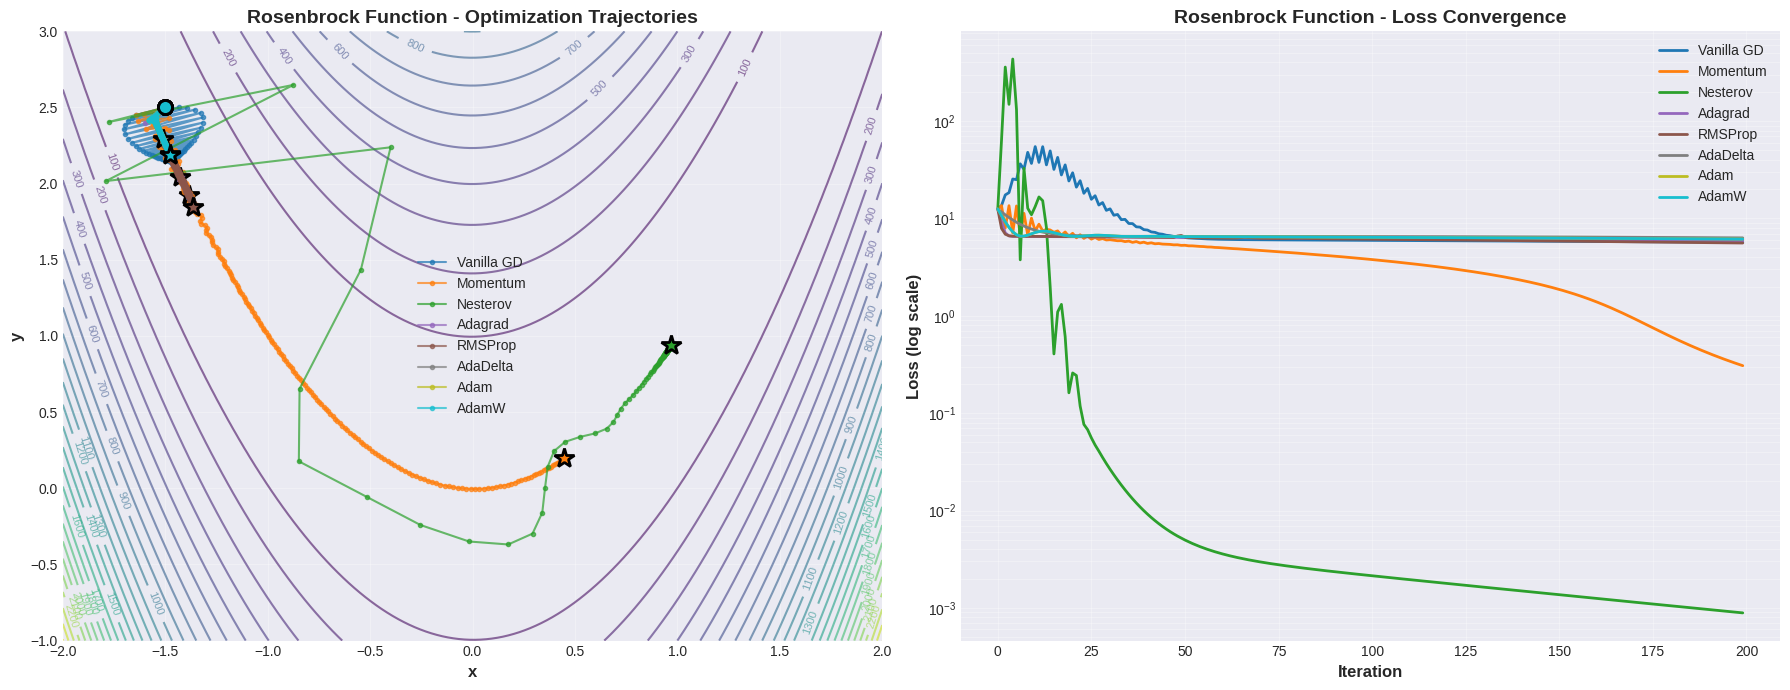


Final Results for Rosenbrock Function:
Optimizer       Final Position            Final Loss      Iterations  
--------------------------------------------------------------------------------
Vanilla GD      (-1.3858,  1.9280)    5.697775e+00    200         
Momentum        ( 0.4464,  0.1962)    3.074007e-01    200         
Nesterov        ( 0.9702,  0.9412)    8.881490e-04    200         
Adagrad         (-1.4275,  2.0440)    5.896734e+00    200         
RMSProp         (-1.3622,  1.8441)    5.593085e+00    200         
AdaDelta        (-1.5122,  2.2943)    6.316832e+00    200         
Adam            (-1.4785,  2.1922)    6.146903e+00    200         
AdamW           (-1.4765,  2.1864)    6.137198e+00    200         



In [22]:
# Configuration for Rosenbrock function
init_pos_rosenbrock = (-1.5, 2.5)  # Starting point
n_iterations = 200

# Define optimizers to compare
optimizers_config = {
    'Vanilla GD': (VanillaGD, {'lr': 0.001}),
    'Momentum': (MomentumOptimizer, {'lr': 0.001, 'momentum': 0.9}),
    'Nesterov': (NesterovOptimizer, {'lr': 0.001, 'momentum': 0.9}),
    'Adagrad': (AdagradOptimizer, {'lr': 0.1}),
    'RMSProp': (RMSPropOptimizer, {'lr': 0.01, 'beta': 0.9}),
    'AdaDelta': (AdaDeltaOptimizer, {'rho': 0.95}),
    'Adam': (AdamOptimizer, {'lr': 0.01}),
    'AdamW': (AdamWOptimizer, {'lr': 0.01, 'weight_decay': 0.001}),
}

# Run optimization for each optimizer
results_rosenbrock = {}

print("Running optimization on Rosenbrock function...")
print(f"Initial position: {init_pos_rosenbrock}")
print(f"Global minimum: (1, 1)\n")

for opt_name, (opt_class, opt_kwargs) in optimizers_config.items():
    print(f"Optimizing with {opt_name}...", end=" ")
    trajectory, losses = optimize_function(
        opt_class, rosenbrock, init_pos_rosenbrock,
        opt_kwargs, n_iterations, "Rosenbrock"
    )
    results_rosenbrock[opt_name] = (trajectory, losses)
    print(f"Final loss: {losses[-1]:.6e}")

# Visualize results
plot_optimization_comparison(
    results_rosenbrock, rosenbrock, "Rosenbrock",
    bounds=(-2, 2, -1, 3), n_points=150
)

### **7.5 Demonstration 2: Beale Function**

The **Beale function** provides a different challenge:
- Multiple local minima and flat regions
- Global minimum at (3, 0.5)
- Tests robustness to local minima and exploration capability

Running optimization on Beale function...
Initial position: (0.5, 0.5)
Global minimum: (3, 0.5)

Optimizing with Vanilla GD... Final loss: 2.029561e+00
Optimizing with Momentum... Final loss: 2.871770e-02
Optimizing with Nesterov... Final loss: 2.953910e-02
Optimizing with Adagrad... Final loss: 4.347402e-01
Optimizing with RMSProp... Final loss: 6.014684e-01
Optimizing with AdaDelta... Final loss: 3.259631e+00
Optimizing with Adam... Final loss: 1.219853e+00
Optimizing with AdamW... Final loss: 1.223477e+00


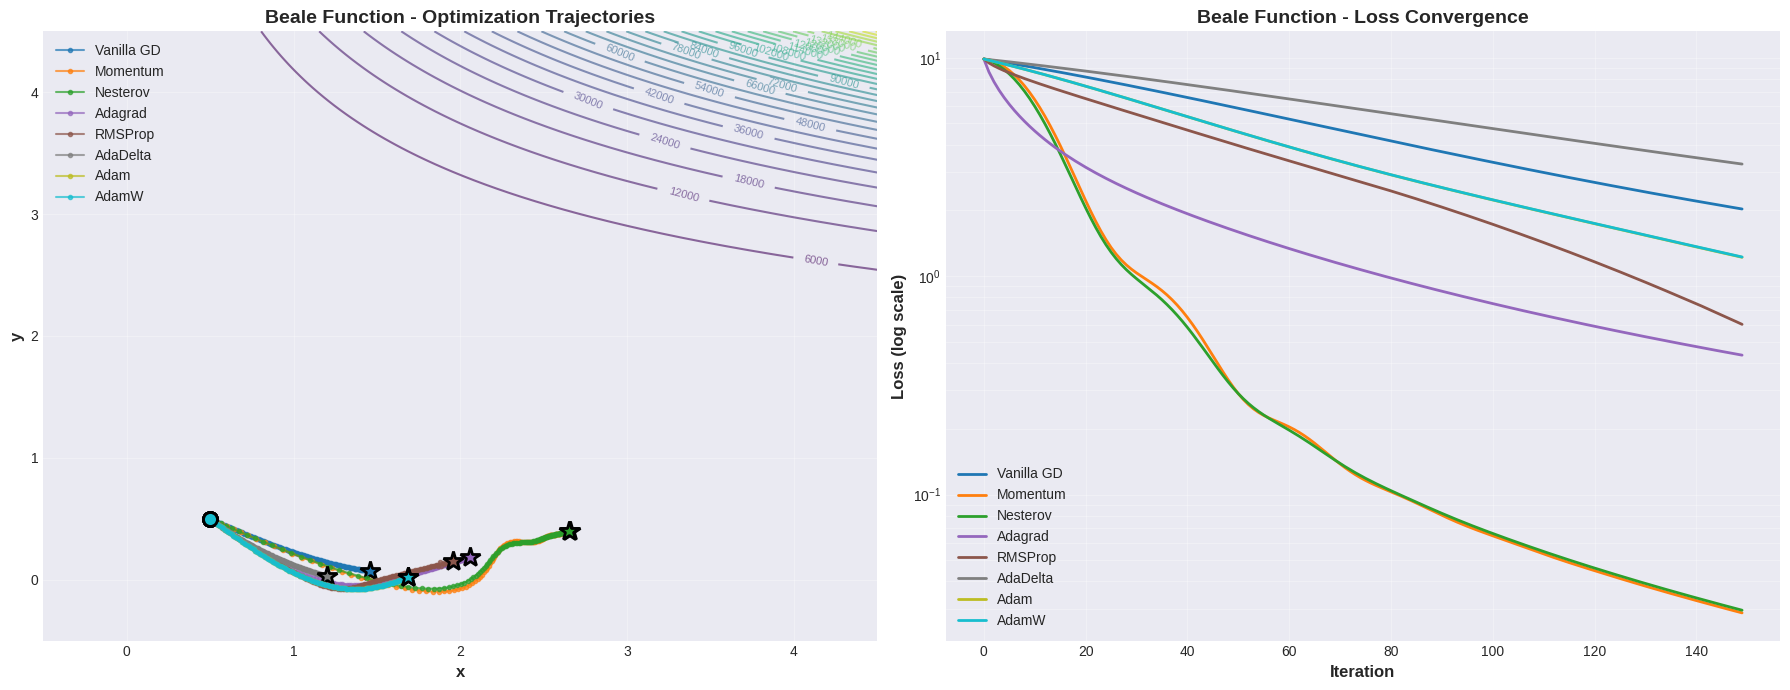


Final Results for Beale Function:
Optimizer       Final Position            Final Loss      Iterations  
--------------------------------------------------------------------------------
Vanilla GD      ( 1.4564,  0.0706)    2.029561e+00    150         
Momentum        ( 2.6545,  0.3998)    2.871770e-02    150         
Nesterov        ( 2.6505,  0.3983)    2.953910e-02    150         
Adagrad         ( 2.0597,  0.1825)    4.347402e-01    150         
RMSProp         ( 1.9535,  0.1516)    6.014684e-01    150         
AdaDelta        ( 1.1982,  0.0312)    3.259631e+00    150         
Adam            ( 1.6876,  0.0191)    1.219853e+00    150         
AdamW           ( 1.6863,  0.0187)    1.223477e+00    150         



In [24]:
# Configuration for Beale function
init_pos_beale = (0.5, 0.5)  # Starting point
n_iterations = 150

# Run optimization for each optimizer
results_beale = {}

print("Running optimization on Beale function...")
print(f"Initial position: {init_pos_beale}")
print(f"Global minimum: (3, 0.5)\n")

for opt_name, (opt_class, opt_kwargs) in optimizers_config.items():
    print(f"Optimizing with {opt_name}...", end=" ")
    trajectory, losses = optimize_function(
        opt_class, beale, init_pos_beale,
        opt_kwargs, n_iterations, "Beale"
    )
    results_beale[opt_name] = (trajectory, losses)
    print(f"Final loss: {losses[-1]:.6e}")

# Visualize results
plot_optimization_comparison(
    results_beale, beale, "Beale",
    bounds=(-0.5, 4.5, -0.5, 4.5), n_points=150
)

## **8. Real-World Application: Neural Network Training**

### **8.1 Problem Setup: Non-Linear Classification**

We'll create a challenging non-linear classification problem using synthetic data with:
- Two-dimensional input features
- Three classes arranged in concentric circles
- A neural network with non-linear activations

This demonstrates optimizer performance in a realistic deep learning scenario.

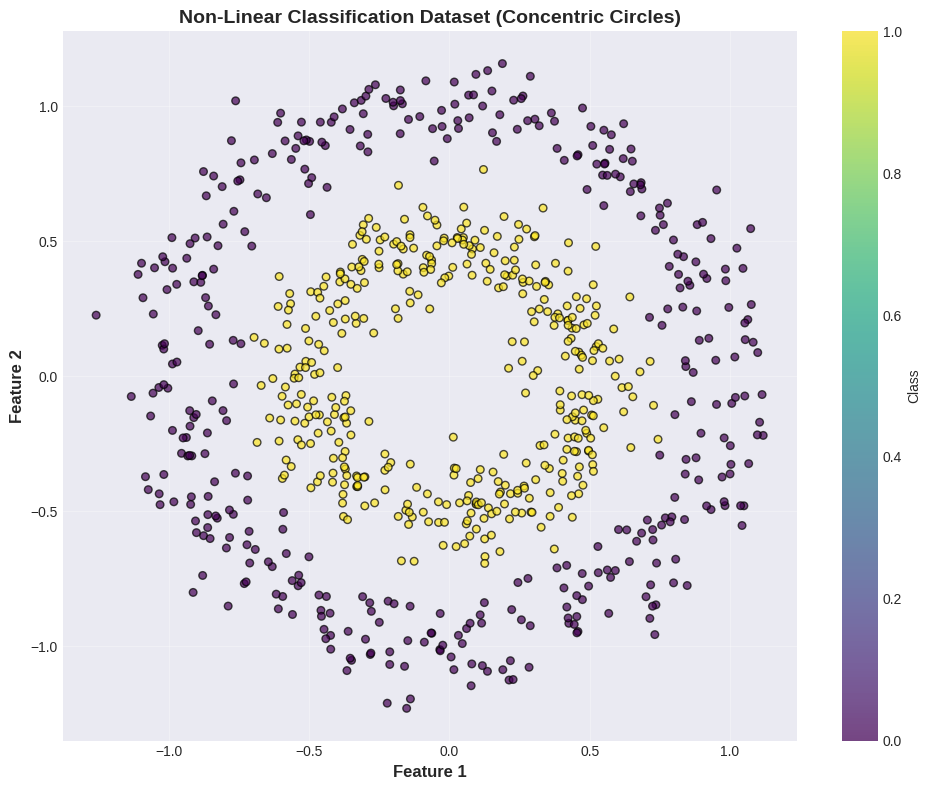

Dataset created:
Training samples: 800
Test samples: 200
Input features: 2
Number of classes: 2


In [25]:
# Generate synthetic non-linear classification dataset
from sklearn.datasets import make_circles

# Create dataset with concentric circles
n_samples = 1000
X_data, y_data = make_circles(n_samples=n_samples, noise=0.1, factor=0.5, random_state=42)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_data)
y_tensor = torch.LongTensor(y_data)

# Split into train and test sets
train_size = int(0.8 * n_samples)
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

# Visualize the dataset
plt.figure(figsize=(10, 8))
plt.scatter(X_train[:, 0].numpy(), X_train[:, 1].numpy(),
           c=y_train.numpy(), cmap='viridis', s=30, alpha=0.7, edgecolors='black')
plt.xlabel('Feature 1', fontsize=12, fontweight='bold')
plt.ylabel('Feature 2', fontsize=12, fontweight='bold')
plt.title('Non-Linear Classification Dataset (Concentric Circles)',
         fontsize=14, fontweight='bold')
plt.colorbar(label='Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dataset created:")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input features: {X_train.shape[1]}")
print(f"Number of classes: {len(torch.unique(y_train))}")

### **8.2 Neural Network Architecture**

In [26]:
class NonLinearClassifier(nn.Module):
    """
    Multi-layer neural network for non-linear classification.

    Architecture:
    - Input Layer: 2 features
    - Hidden Layer 1: 64 neurons with ReLU activation
    - Hidden Layer 2: 32 neurons with ReLU activation
    - Hidden Layer 3: 16 neurons with ReLU activation
    - Output Layer: 2 classes (binary classification)

    This architecture is sufficiently complex to demonstrate
    optimizer differences in a realistic scenario.
    """

    def __init__(self, input_dim=2, hidden_dims=[64, 32, 16], output_dim=2):
        """
        Initialize the neural network.

        Parameters:
        -----------
        input_dim : int
            Number of input features
        hidden_dims : list of int
            Dimensions of hidden layers
        output_dim : int
            Number of output classes
        """
        super(NonLinearClassifier, self).__init__()

        # Build layers dynamically
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim)
            ])
            prev_dim = hidden_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """Forward pass through the network."""
        return self.network(x)

# Test the model
model_test = NonLinearClassifier()
print("Neural Network Architecture:")
print("="*60)
print(model_test)
print("="*60)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters())}")

Neural Network Architecture:
NonLinearClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=16, out_features=2, bias=True)
  )
)

Total parameters: 3058


### **8.3 Training Function**

In [28]:
def train_model(model, optimizer, X_train, y_train, X_test, y_test,
                n_epochs=100, verbose=False):
    """
    Train a neural network and track performance metrics.

    Parameters:
    -----------
    model : nn.Module
        Neural network to train
    optimizer : optimizer object
        Optimizer instance (custom or PyTorch)
    X_train, y_train : torch.Tensor
        Training data and labels
    X_test, y_test : torch.Tensor
        Test data and labels
    n_epochs : int
        Number of training epochs
    verbose : bool
        Whether to print progress

    Returns:
    --------
    train_losses : list
        Training loss per epoch
    test_losses : list
        Test loss per epoch
    train_accs : list
        Training accuracy per epoch
    test_accs : list
        Test accuracy per epoch
    """
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(n_epochs):
        # Training phase
        model.train()
        optimizer.zero_grad()

        # Forward pass
        train_outputs = model(X_train)
        train_loss = criterion(train_outputs, y_train)

        # Backward pass and optimization
        train_loss.backward()
        optimizer.step()

        # Calculate training accuracy
        _, train_preds = torch.max(train_outputs, 1)
        train_acc = (train_preds == y_train).float().mean()

        # Evaluation phase
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)
            _, test_preds = torch.max(test_outputs, 1)
            test_acc = (test_preds == y_test).float().mean()

        # Store metrics
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc.item())
        test_accs.append(test_acc.item())

        # Print progress
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{n_epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    return train_losses, test_losses, train_accs, test_accs

### **8.4 Comparison: Custom Implementations**

Let's train the neural network using our custom optimizer implementations.

In [29]:
# Training configuration
n_epochs = 100
results_nn = {}

# Define optimizers for neural network training
nn_optimizers = {
    'Vanilla GD': (VanillaGD, {'lr': 0.01}),
    'Momentum': (MomentumOptimizer, {'lr': 0.01, 'momentum': 0.9}),
    'Adam': (AdamOptimizer, {'lr': 0.001}),
    'AdamW': (AdamWOptimizer, {'lr': 0.001, 'weight_decay': 0.01}),
    'RMSProp': (RMSPropOptimizer, {'lr': 0.001}),
}

print("Training neural networks with custom optimizers...")
print("="*80)

for opt_name, (opt_class, opt_kwargs) in nn_optimizers.items():
    print(f"\nTraining with {opt_name}:")
    print("-"*80)

    # Create fresh model
    model = NonLinearClassifier()

    # Initialize optimizer
    optimizer = opt_class(model.parameters(), **opt_kwargs)

    # Train model
    train_losses, test_losses, train_accs, test_accs = train_model(
        model, optimizer, X_train, y_train, X_test, y_test,
        n_epochs=n_epochs, verbose=True
    )

    # Store results
    results_nn[opt_name] = {
        'train_loss': train_losses,
        'test_loss': test_losses,
        'train_acc': train_accs,
        'test_acc': test_accs
    }

    print(f"Final - Train Acc: {train_accs[-1]:.4f}, Test Acc: {test_accs[-1]:.4f}")

print("\n" + "="*80)

Training neural networks with custom optimizers...

Training with Vanilla GD:
--------------------------------------------------------------------------------
Epoch [20/100] - Train Loss: 0.3961, Train Acc: 0.9737 | Test Loss: 0.6293, Test Acc: 0.8100
Epoch [40/100] - Train Loss: 0.2857, Train Acc: 0.9925 | Test Loss: 0.4054, Test Acc: 0.9200
Epoch [60/100] - Train Loss: 0.2137, Train Acc: 0.9950 | Test Loss: 0.2390, Test Acc: 0.9650
Epoch [80/100] - Train Loss: 0.1657, Train Acc: 0.9962 | Test Loss: 0.1709, Test Acc: 0.9750
Epoch [100/100] - Train Loss: 0.1334, Train Acc: 0.9962 | Test Loss: 0.1359, Test Acc: 0.9800
Final - Train Acc: 0.9962, Test Acc: 0.9800

Training with Momentum:
--------------------------------------------------------------------------------
Epoch [20/100] - Train Loss: 0.1459, Train Acc: 0.9750 | Test Loss: 0.6424, Test Acc: 0.5450
Epoch [40/100] - Train Loss: 0.0296, Train Acc: 0.9962 | Test Loss: 0.1678, Test Acc: 0.9500
Epoch [60/100] - Train Loss: 0.0152, Tr

### **8.5 Visualization: Neural Network Training Results**

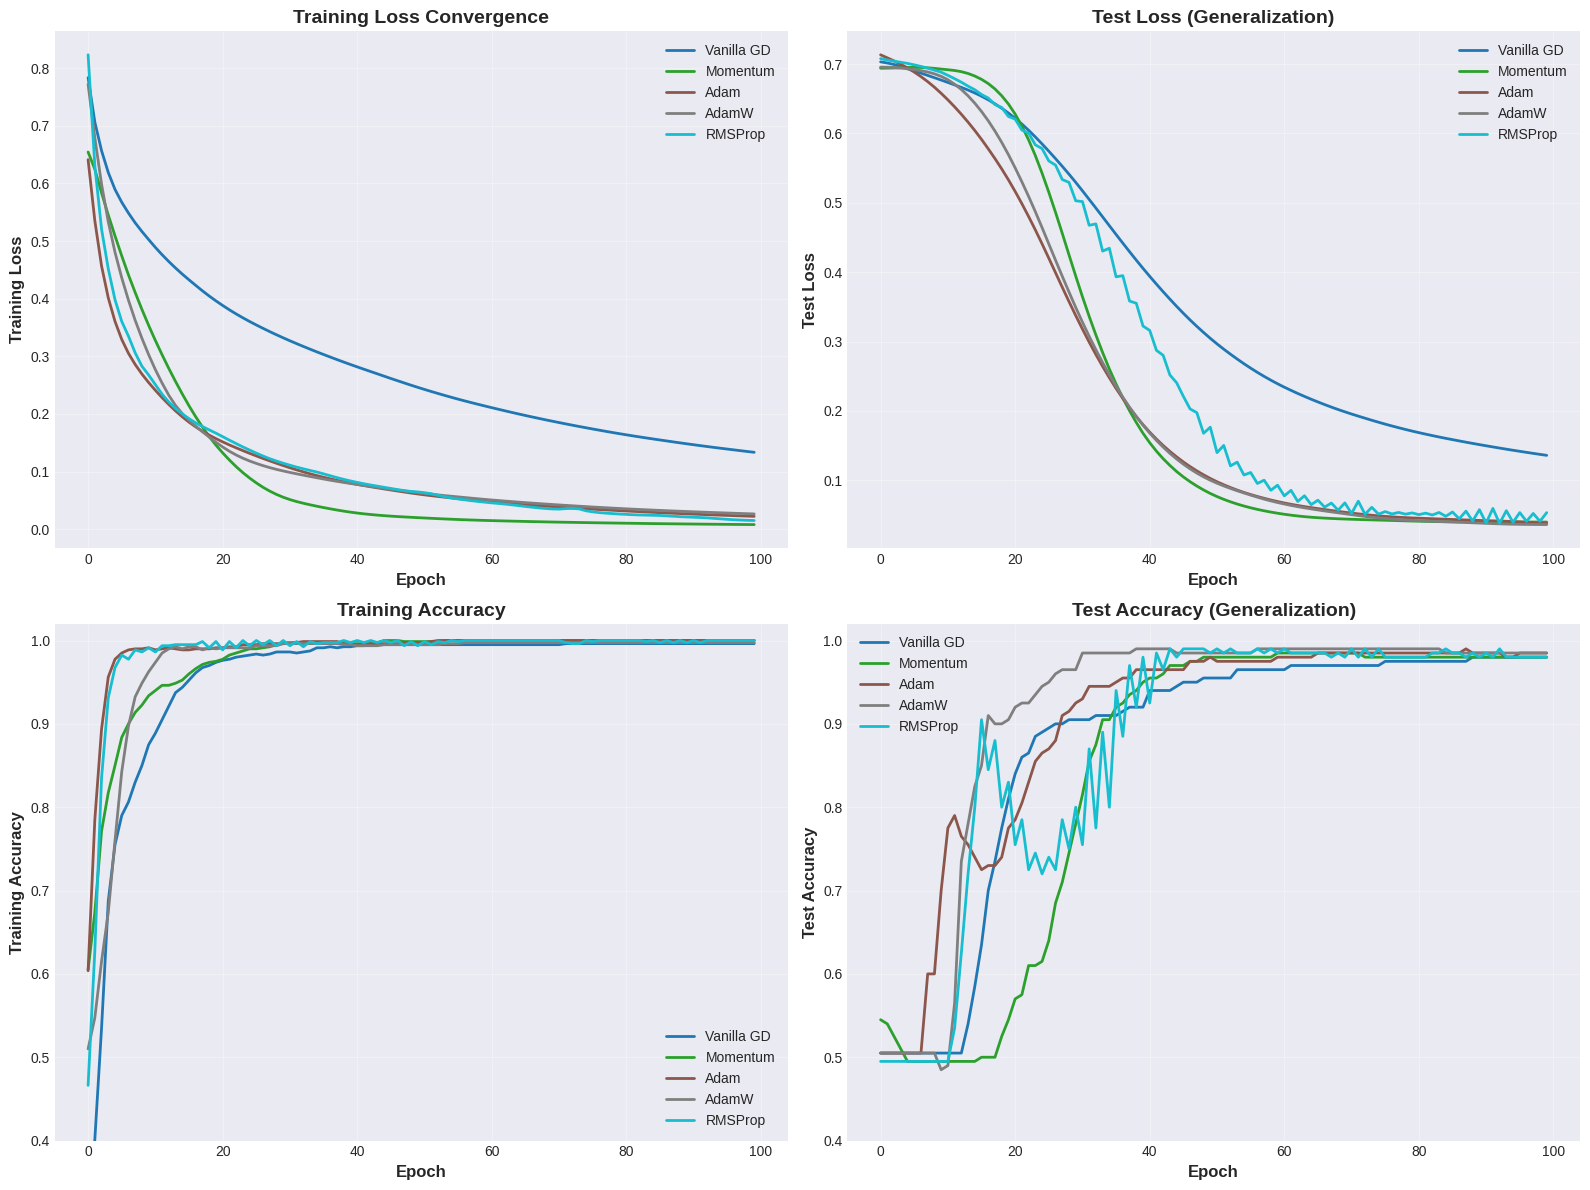


Final Performance Summary:
Optimizer       Train Loss   Test Loss    Train Acc    Test Acc    
--------------------------------------------------------------------------------
Vanilla GD      0.1334       0.1359       0.9962       0.9800      
Momentum        0.0080       0.0397       1.0000       0.9800      
Adam            0.0223       0.0380       1.0000       0.9850      
AdamW           0.0265       0.0361       0.9975       0.9850      
RMSProp         0.0151       0.0533       1.0000       0.9800      


In [30]:
# Visualize training results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = plt.cm.tab10(np.linspace(0, 1, len(results_nn)))

# Plot 1: Training Loss
ax = axes[0, 0]
for (opt_name, metrics), color in zip(results_nn.items(), colors):
    ax.plot(metrics['train_loss'], label=opt_name, color=color, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Test Loss
ax = axes[0, 1]
for (opt_name, metrics), color in zip(results_nn.items(), colors):
    ax.plot(metrics['test_loss'], label=opt_name, color=color, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Loss', fontsize=12, fontweight='bold')
ax.set_title('Test Loss (Generalization)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Training Accuracy
ax = axes[1, 0]
for (opt_name, metrics), color in zip(results_nn.items(), colors):
    ax.plot(metrics['train_acc'], label=opt_name, color=color, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.02])

# Plot 4: Test Accuracy
ax = axes[1, 1]
for (opt_name, metrics), color in zip(results_nn.items(), colors):
    ax.plot(metrics['test_acc'], label=opt_name, color=color, linewidth=2)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Test Accuracy (Generalization)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.02])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("Final Performance Summary:")
print("="*80)
print(f"{'Optimizer':<15} {'Train Loss':<12} {'Test Loss':<12} {'Train Acc':<12} {'Test Acc':<12}")
print("-"*80)

for opt_name, metrics in results_nn.items():
    print(f"{opt_name:<15} {metrics['train_loss'][-1]:<12.4f} {metrics['test_loss'][-1]:<12.4f} "
          f"{metrics['train_acc'][-1]:<12.4f} {metrics['test_acc'][-1]:<12.4f}")

print("="*80)

## **9. Comparison with PyTorch Built-in Optimizers**

### **9.1 PyTorch Optimizer Overview**

PyTorch provides highly optimized implementations of all major optimizers in the `torch.optim` module:

| **PyTorch Class** | **Equivalent Custom Class** | **Key Parameters** |
|-------------------|-----------------------------|--------------------|
| `torch.optim.SGD` | `VanillaGD` / `MomentumOptimizer` | `lr`, `momentum`, `nesterov` |
| `torch.optim.Adagrad` | `AdagradOptimizer` | `lr`, `eps` |
| `torch.optim.RMSprop` | `RMSPropOptimizer` | `lr`, `alpha` (β), `eps` |
| `torch.optim.Adadelta` | `AdaDeltaOptimizer` | `rho`, `eps` |
| `torch.optim.Adam` | `AdamOptimizer` | `lr`, `betas` (β₁, β₂), `eps` |
| `torch.optim.AdamW` | `AdamWOptimizer` | `lr`, `betas`, `eps`, `weight_decay` |

**Key Advantages of PyTorch Optimizers:**
1. **Highly optimized C++/CUDA implementations** for performance
2. **Additional features**: Learning rate schedulers, gradient clipping, etc.
3. **Production-ready**: Extensively tested and maintained
4. **Advanced options**: AMSGrad, foreach implementation, fused operations

**When to Use Custom vs PyTorch Optimizers:**
- **Custom**: Educational purposes, experimentation, novel research
- **PyTorch**: Production code, performance-critical applications, standard training

### **9.2 Training with PyTorch Optimizers**

In [31]:
# PyTorch optimizers configuration
pytorch_optimizers = {
    'PyTorch SGD': (optim.SGD, {'lr': 0.01}),
    'PyTorch Momentum': (optim.SGD, {'lr': 0.01, 'momentum': 0.9}),
    'PyTorch Nesterov': (optim.SGD, {'lr': 0.01, 'momentum': 0.9, 'nesterov': True}),
    'PyTorch Adagrad': (optim.Adagrad, {'lr': 0.01}),
    'PyTorch RMSprop': (optim.RMSprop, {'lr': 0.001}),
    'PyTorch Adadelta': (optim.Adadelta, {'rho': 0.95}),
    'PyTorch Adam': (optim.Adam, {'lr': 0.001}),
    'PyTorch AdamW': (optim.AdamW, {'lr': 0.001, 'weight_decay': 0.01}),
}

results_pytorch = {}

print("Training neural networks with PyTorch optimizers...")
print("="*80)

for opt_name, (opt_class, opt_kwargs) in pytorch_optimizers.items():
    print(f"\nTraining with {opt_name}:")
    print("-"*80)

    # Create fresh model
    model = NonLinearClassifier()

    # Initialize PyTorch optimizer
    optimizer = opt_class(model.parameters(), **opt_kwargs)

    # Train model
    train_losses, test_losses, train_accs, test_accs = train_model(
        model, optimizer, X_train, y_train, X_test, y_test,
        n_epochs=n_epochs, verbose=True
    )

    # Store results
    results_pytorch[opt_name] = {
        'train_loss': train_losses,
        'test_loss': test_losses,
        'train_acc': train_accs,
        'test_acc': test_accs
    }

    print(f"Final - Train Acc: {train_accs[-1]:.4f}, Test Acc: {test_accs[-1]:.4f}")

print("\n" + "="*80)
print("Training complete!")

Training neural networks with PyTorch optimizers...

Training with PyTorch SGD:
--------------------------------------------------------------------------------
Epoch [20/100] - Train Loss: 0.3149, Train Acc: 0.9800 | Test Loss: 0.6076, Test Acc: 0.9150
Epoch [40/100] - Train Loss: 0.2029, Train Acc: 0.9887 | Test Loss: 0.3112, Test Acc: 0.9850
Epoch [60/100] - Train Loss: 0.1461, Train Acc: 0.9912 | Test Loss: 0.1607, Test Acc: 0.9900
Epoch [80/100] - Train Loss: 0.1083, Train Acc: 0.9937 | Test Loss: 0.1066, Test Acc: 0.9900
Epoch [100/100] - Train Loss: 0.0884, Train Acc: 0.9937 | Test Loss: 0.0851, Test Acc: 0.9850
Final - Train Acc: 0.9937, Test Acc: 0.9850

Training with PyTorch Momentum:
--------------------------------------------------------------------------------
Epoch [20/100] - Train Loss: 0.1393, Train Acc: 0.9825 | Test Loss: 0.6492, Test Acc: 0.5250
Epoch [40/100] - Train Loss: 0.0422, Train Acc: 0.9962 | Test Loss: 0.1405, Test Acc: 0.9500
Epoch [60/100] - Train Loss: 

### **9.3 Side-by-Side Comparison**

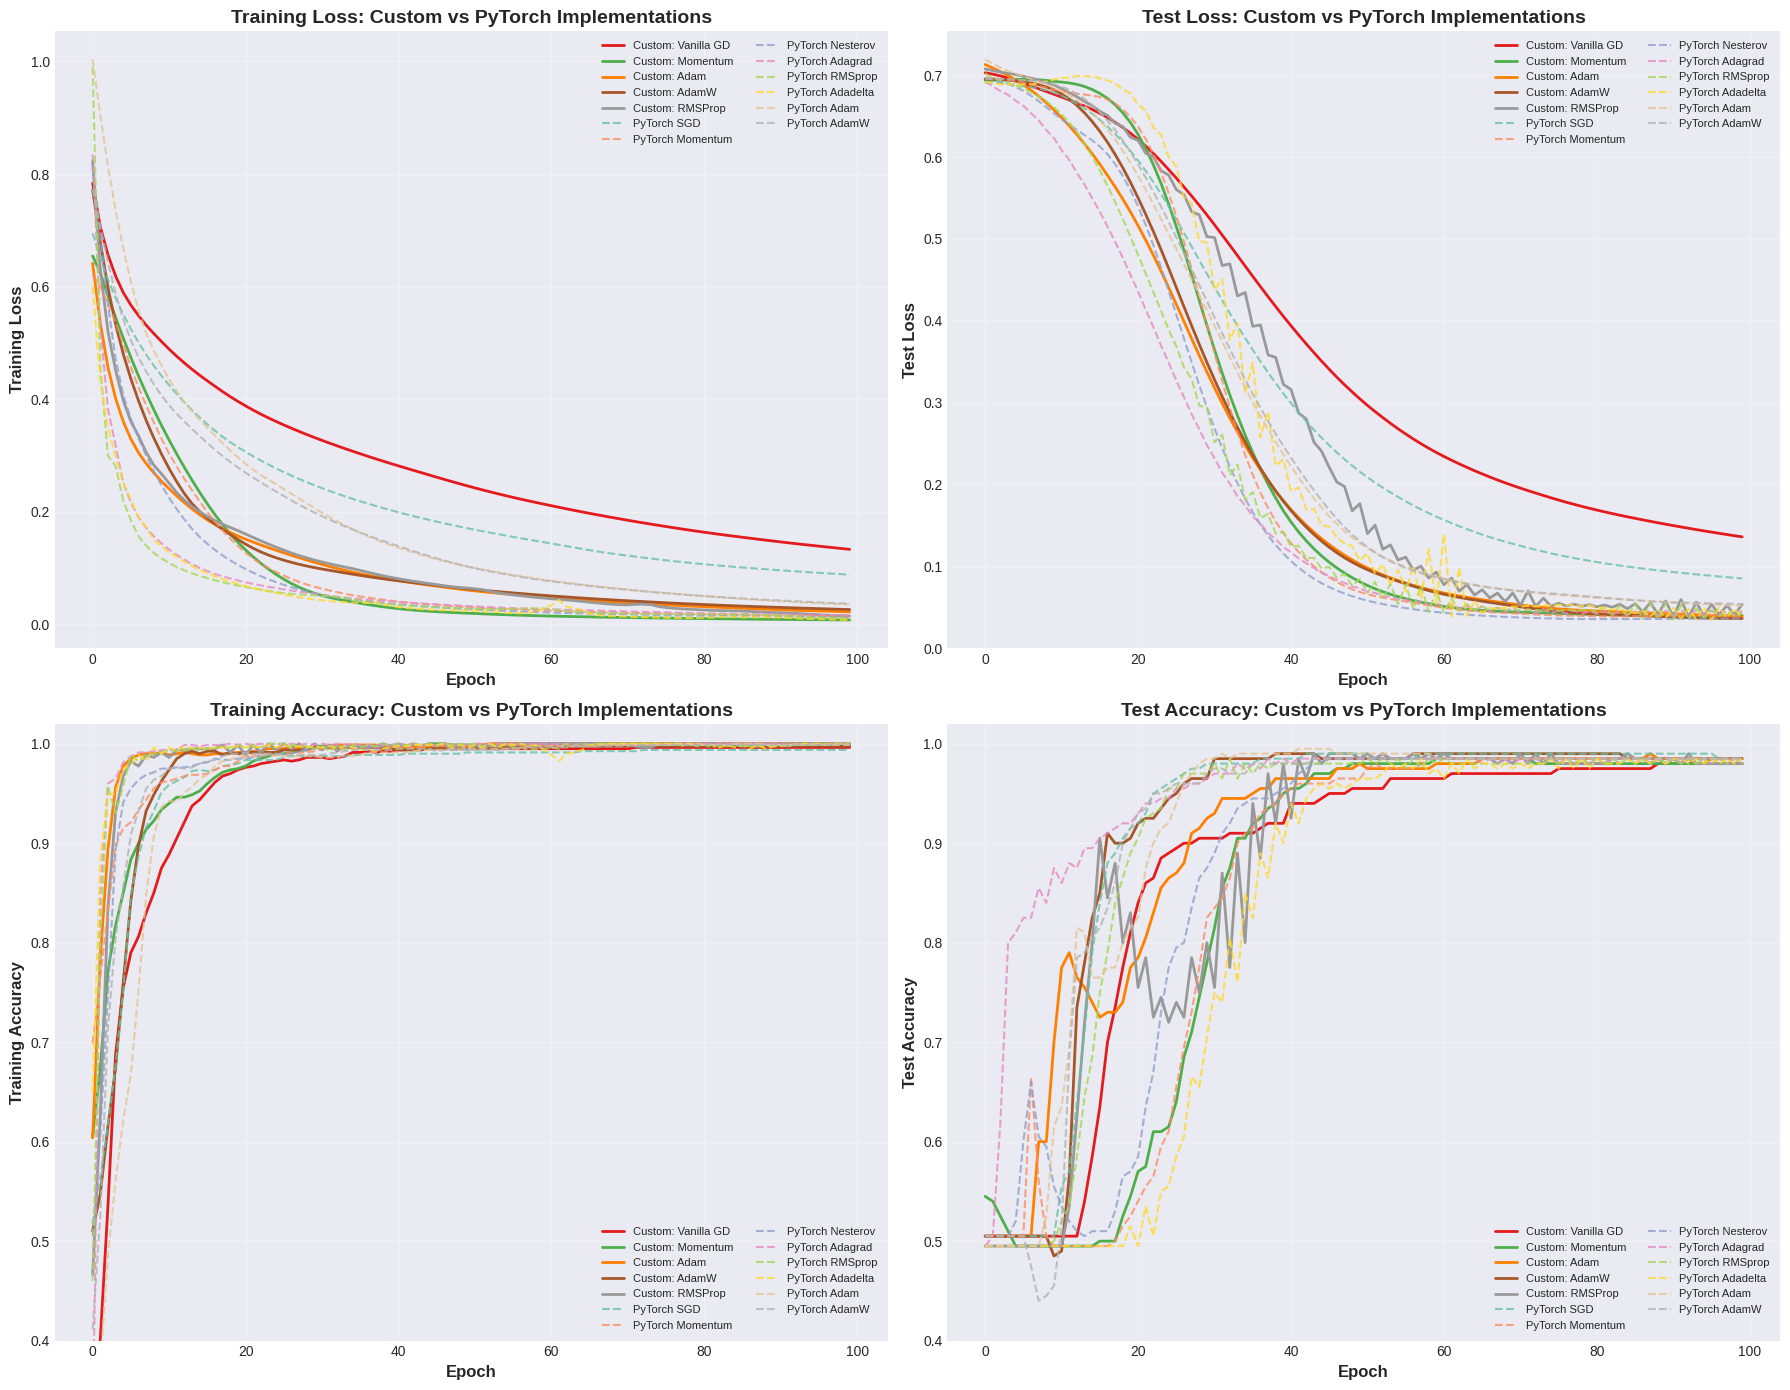


Comprehensive Comparison: Custom vs PyTorch Implementations
Optimizer                      Type       Final Train Acc    Final Test Acc    
----------------------------------------------------------------------------------------------------
Vanilla GD                     Custom     0.9962             0.9800            
Momentum                       Custom     1.0000             0.9800            
Adam                           Custom     1.0000             0.9850            
AdamW                          Custom     0.9975             0.9850            
RMSProp                        Custom     1.0000             0.9800            
PyTorch SGD                    PyTorch    0.9937             0.9850            
PyTorch Momentum               PyTorch    1.0000             0.9850            
PyTorch Nesterov               PyTorch    1.0000             0.9850            
PyTorch Adagrad                PyTorch    1.0000             0.9800            
PyTorch RMSprop                PyTorch

In [32]:
# Combine results for comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Define color schemes
custom_colors = plt.cm.Set1(np.linspace(0, 1, len(results_nn)))
pytorch_colors = plt.cm.Set2(np.linspace(0, 1, len(results_pytorch)))

# Plot 1: Training Loss Comparison
ax = axes[0, 0]
for (opt_name, metrics), color in zip(results_nn.items(), custom_colors):
    ax.plot(metrics['train_loss'], label=f'Custom: {opt_name}',
           color=color, linewidth=2, linestyle='-')
for (opt_name, metrics), color in zip(results_pytorch.items(), pytorch_colors):
    ax.plot(metrics['train_loss'], label=opt_name,
           color=color, linewidth=1.5, linestyle='--', alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Loss: Custom vs PyTorch Implementations',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.grid(True, alpha=0.3)

# Plot 2: Test Loss Comparison
ax = axes[0, 1]
for (opt_name, metrics), color in zip(results_nn.items(), custom_colors):
    ax.plot(metrics['test_loss'], label=f'Custom: {opt_name}',
           color=color, linewidth=2, linestyle='-')
for (opt_name, metrics), color in zip(results_pytorch.items(), pytorch_colors):
    ax.plot(metrics['test_loss'], label=opt_name,
           color=color, linewidth=1.5, linestyle='--', alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Loss', fontsize=12, fontweight='bold')
ax.set_title('Test Loss: Custom vs PyTorch Implementations',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.grid(True, alpha=0.3)

# Plot 3: Training Accuracy Comparison
ax = axes[1, 0]
for (opt_name, metrics), color in zip(results_nn.items(), custom_colors):
    ax.plot(metrics['train_acc'], label=f'Custom: {opt_name}',
           color=color, linewidth=2, linestyle='-')
for (opt_name, metrics), color in zip(results_pytorch.items(), pytorch_colors):
    ax.plot(metrics['train_acc'], label=opt_name,
           color=color, linewidth=1.5, linestyle='--', alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Training Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training Accuracy: Custom vs PyTorch Implementations',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.02])

# Plot 4: Test Accuracy Comparison
ax = axes[1, 1]
for (opt_name, metrics), color in zip(results_nn.items(), custom_colors):
    ax.plot(metrics['test_acc'], label=f'Custom: {opt_name}',
           color=color, linewidth=2, linestyle='-')
for (opt_name, metrics), color in zip(results_pytorch.items(), pytorch_colors):
    ax.plot(metrics['test_acc'], label=opt_name,
           color=color, linewidth=1.5, linestyle='--', alpha=0.8)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Test Accuracy: Custom vs PyTorch Implementations',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='best', ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.02])

plt.tight_layout()
plt.show()

# Print comprehensive comparison
print("\n" + "="*100)
print("Comprehensive Comparison: Custom vs PyTorch Implementations")
print("="*100)
print(f"{'Optimizer':<30} {'Type':<10} {'Final Train Acc':<18} {'Final Test Acc':<18}")
print("-"*100)

for opt_name, metrics in results_nn.items():
    print(f"{opt_name:<30} {'Custom':<10} {metrics['train_acc'][-1]:<18.4f} "
          f"{metrics['test_acc'][-1]:<18.4f}")

for opt_name, metrics in results_pytorch.items():
    print(f"{opt_name:<30} {'PyTorch':<10} {metrics['train_acc'][-1]:<18.4f} "
          f"{metrics['test_acc'][-1]:<18.4f}")

print("="*100)

## **10. Key Insights and Best Practices**

### **10.1 Summary of Optimizer Characteristics**

#### **Convergence Speed Hierarchy (Generally)**

$$\text{Adam/AdamW} \approx \text{RMSProp} > \text{Momentum/Nesterov} > \text{AdaDelta} > \text{Adagrad} > \text{Vanilla GD}$$

#### **Optimizer Selection Guide**

| **Scenario** | **Recommended Optimizer** | **Rationale** |
|--------------|--------------------------|---------------|
| **General Deep Learning** | Adam or AdamW | Best balance of speed and robustness |
| **Computer Vision (CNNs)** | SGD with Momentum or AdamW | Better generalization, proven track record |
| **Natural Language Processing** | Adam or AdamW | Handles sparse gradients well |
| **Transformer Models** | AdamW | Industry standard, decoupled weight decay |
| **Sparse Data/Features** | Adagrad or Adam | Adaptive per-parameter learning rates |
| **RNNs/LSTMs** | RMSProp or Adam | Handles non-stationary objectives |
| **Fine-tuning Pre-trained Models** | AdamW with low LR | Preserves learned features |
| **Convex Optimization** | SGD or Nesterov | Strong convergence guarantees |
| **Need Fast Prototyping** | Adam | Works well with default hyperparameters |
| **Memory Constrained** | Vanilla SGD or Momentum | Lowest memory overhead |

### **10.2 Hyperparameter Tuning Guidelines**

#### **Learning Rate Selection**

| **Optimizer** | **Typical LR Range** | **Starting Point** |
|---------------|---------------------|-------------------|
| Vanilla GD | 0.001 - 0.1 | 0.01 |
| Momentum | 0.001 - 0.1 | 0.01 |
| Adagrad | 0.01 - 1.0 | 0.1 |
| RMSProp | 0.0001 - 0.01 | 0.001 |
| AdaDelta | N/A (adaptive) | Default (ρ=0.95) |
| Adam | 0.0001 - 0.01 | 0.001 |
| AdamW | 0.0001 - 0.01 | 0.001 |

#### **Other Hyperparameters**

**Momentum-based:**
- $\beta$ (momentum): 0.9 (standard), 0.99 (smooth landscapes)

**Adaptive methods:**
- $\beta_1$ (Adam): 0.9 (gradient momentum)
- $\beta_2$ (Adam): 0.999 (squared gradient momentum)
- $\epsilon$: $10^{-8}$ (numerical stability)

**Weight Decay (AdamW):**
- Computer Vision: 0.01 - 0.1
- NLP: 0.01 - 0.001
- Fine-tuning: 0.0001 - 0.001

### **10.3 Common Pitfalls and Solutions**

| **Problem** | **Possible Causes** | **Solutions** |
|-------------|-------------------|---------------|
| **Training loss not decreasing** | LR too small, poor initialization | Increase LR, use proper initialization |
| **Loss exploding** | LR too large | Decrease LR, gradient clipping |
| **Slow convergence** | Inappropriate optimizer, poor LR | Try Adam/AdamW, LR scheduling |
| **Overfitting** | No regularization | Use AdamW, dropout, data augmentation |
| **Oscillating loss** | LR too high for vanilla GD | Add momentum or reduce LR |
| **Stuck in local minimum** | No momentum | Use momentum-based optimizer |
| **Poor generalization with Adam** | Weight decay interaction | Switch to AdamW |

### **10.4 Modern Best Practices (2025)**

1. **Default Choice**: Start with **AdamW** (lr=0.001, weight_decay=0.01)

2. **For Better Generalization**: Use **SGD with Momentum** + **Learning Rate Scheduling**

3. **Learning Rate Scheduling**: Combine optimizers with:
   - Cosine annealing
   - ReduceLROnPlateau
   - Warm-up strategies

4. **Gradient Clipping**: Essential for RNNs and Transformers
   ```python
   torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
   ```

5. **Mixed Precision Training**: Use with Adam/AdamW for large models
   ```python
   from torch.cuda.amp import autocast, GradScaler
   ```

6. **Batch Size Considerations**:
   - Larger batches → Increase learning rate proportionally
   - Small batches → More noise, may need momentum

7. **Warm Restarts**: Combine with cosine annealing for better exploration